# 🎤 Speech Emotion Recognition using Deep Learning

## Objective
This project recognizes human emotions (happy, sad, angry, etc.) from speech audio using MFCC features and a Convolutional Neural Network (CNN).

## Dataset
RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)

## Approach
- Audio preprocessing using Librosa
- Feature extraction (MFCC)
- Deep Learning model (CNN)

---
## Step 1: Import Required Libraries
Import libraries for audio processing, data handling, machine learning, and deep learning.

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
!pip install librosa

---
## Step 2: Load Dataset Path
Defining the location of the RAVDESS dataset folders.

In [2]:
import os

DATA_PATH = r"C:\Users\ORACLE\Speech_Emotion_Project\Audio_Speech_Actors_Datasets"

print(os.listdir(DATA_PATH))

['Actor_01', 'Actor_02', 'Actor_03', 'Actor_04', 'Actor_05', 'Actor_06', 'Actor_07', 'Actor_08', 'Actor_09', 'Actor_10', 'Actor_11', 'Actor_12', 'Actor_13', 'Actor_14', 'Actor_15', 'Actor_16', 'Actor_17', 'Actor_18', 'Actor_19', 'Actor_20', 'Actor_21', 'Actor_22', 'Actor_23', 'Actor_24']


---
## Step 3: Emotion Labels Mapping
Each audio file contains a code that represents an emotion.

In [3]:
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

---
## Step 4: Extract MFCC Features from Audio
Convert audio files into MFCC (Mel-Frequency Cepstral Coefficients), which represent sound features for deep learning.

In [4]:
def extract_mfcc_augmented(file_path, max_pad_len=174, augment=False):
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)
    
    if augment:
        choice = np.random.randint(3)
        if choice == 0:
            audio = audio + 0.005 * np.random.randn(len(audio))
        elif choice == 1:
            audio = librosa.effects.time_stretch(audio, rate=np.random.uniform(0.9, 1.1))
        elif choice == 2:
            audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=np.random.randint(-2, 3))
    
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    pad_width = max_pad_len - mfcc.shape[1]
    if pad_width > 0:
        mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
    return mfcc

---
## Step 5: Load Audio Files and Extract Features
Loop through all audio files, extract MFCC features, and store labels.

In [5]:
X = []
y = []

for actor in os.listdir(DATA_PATH):
    actor_path = os.path.join(DATA_PATH, actor)
    
    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            file_path = os.path.join(actor_path, file)
            
            emotion_code = file.split("-")[2]
            emotion = emotion_map[emotion_code]
            
            # Original (augment=False)
            mfcc = extract_mfcc_augmented(file_path, augment=False)
            X.append(mfcc)
            y.append(emotion)
            
            # Augmented copy (augment=True)
            mfcc_aug = extract_mfcc_augmented(file_path, augment=True)
            X.append(mfcc_aug)
            y.append(emotion)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape, y.shape)  # Should be ~2880 now

Dataset shape: (2880, 40, 174) (2880,)


---
## Step 6: Convert Labels to Numbers
Encode emotions, since machine learning models work with numbers.

In [6]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


---
## Step 7: Normalize and Split Dataset
Normalize the input data to improve model stability, then split into training and testing sets.


In [7]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler = StandardScaler()
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
X_test_reshaped  = X_test.reshape(X_test.shape[0], -1)

X_train_scaled = scaler.fit_transform(X_train_reshaped)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test_reshaped)         # transform test

X_train = X_train_scaled.reshape(-1, 40, 174)
X_test  = X_test_scaled.reshape(-1, 40, 174)


In [8]:
import numpy as np
unique, counts = np.unique(y, return_counts=True)

for u, c in zip(unique, counts):
    print(u, c)

angry 192
calm 192
disgust 192
fearful 192
happy 192
neutral 96
sad 192
surprised 192


---
## Step 8: Reshape Data for CNN Input

Convolutional Neural Networks (CNNs) expect input in 4D format:

( samples, height, width, channels )

Since MFCC features are 2D (40 × 174), we add an extra dimension to represent a single channel (like grayscale images).

In [8]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2304, 40, 174, 1)
X_test shape: (576, 40, 174, 1)


---
## Step 9: Build Convolutional Neural Network (CNN)

Build a CNN model to learn patterns from MFCC features.

CNN is effective for this task because MFCC data is similar to images (2D frequency-time representation).

The model consists of:
- Convolution layers (feature extraction)
- MaxPooling layers (dimensionality reduction)
- Dense layers (classification)
- Dropout (to prevent overfitting)

In [9]:
model = models.Sequential([
    tf.keras.Input(shape=(40, 174, 1)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(8, activation='softmax')
])

In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 40, 174, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 40, 174, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 20, 87, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 20, 87, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 20, 87, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 20, 87, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 10, 43, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 10, 43, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 10, 43, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 5, 21, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 5, 21, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 13440)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,440,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           2,056 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,537,544 (13.49 MB)

 Trainable params: 3,536,584 (13.49 MB)

 Non-trainable params: 960 (3.75 KB)

---
## Step 10: Train the CNN Model

Train the model using the training dataset and validate it on unseen test data.

During training, the model learns patterns in MFCC features to classify emotions.

### Step: Early Stopping Callback

We use Early Stopping to automatically stop training when validation loss stops improving.
This helps prevent overfitting.

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 436ms/step - accuracy: 0.3021 - loss: 2.1676 - val_accuracy: 0.1458 - val_loss: 3.9744
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 394ms/step - accuracy: 0.4449 - loss: 1.6002 - val_accuracy: 0.1441 - val_loss: 3.9785
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 396ms/step - accuracy: 0.5673 - loss: 1.2618 - val_accuracy: 0.2691 - val_loss: 2.8446
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 391ms/step - accuracy: 0.6324 - loss: 1.0588 - val_accuracy: 0.3715 - val_loss: 2.0682
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 471ms/step - accuracy: 0.7057 - loss: 0.8303 - val_accuracy: 0.4705 - val_loss: 1.5766
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 37s 414ms/step - accuracy: 0.7843 - loss: 0.6350 - val_accuracy: 0.6024 - val_loss: 1.2236
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 444ms/step - accuracy: 0.8242 - loss: 0.5145 - val_accuracy: 0.6545 - val_loss: 0.9957
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 433ms/step - accuracy: 0.8490 - loss: 0.4288 - val_accu

---
## Step 11: Save Model and Preprocessing Objects
Save the trained model, scaler, and label encoder for future use and deployment.

In [13]:
# Save model
model.save('speech_emotion_model.h5')

# Save scaler and label encoder (needed for predictions later)
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

---
## Step 12: Plot Training Accuracy and Loss Curves
We visualize how the model's accuracy and loss changed over each epoch during training.

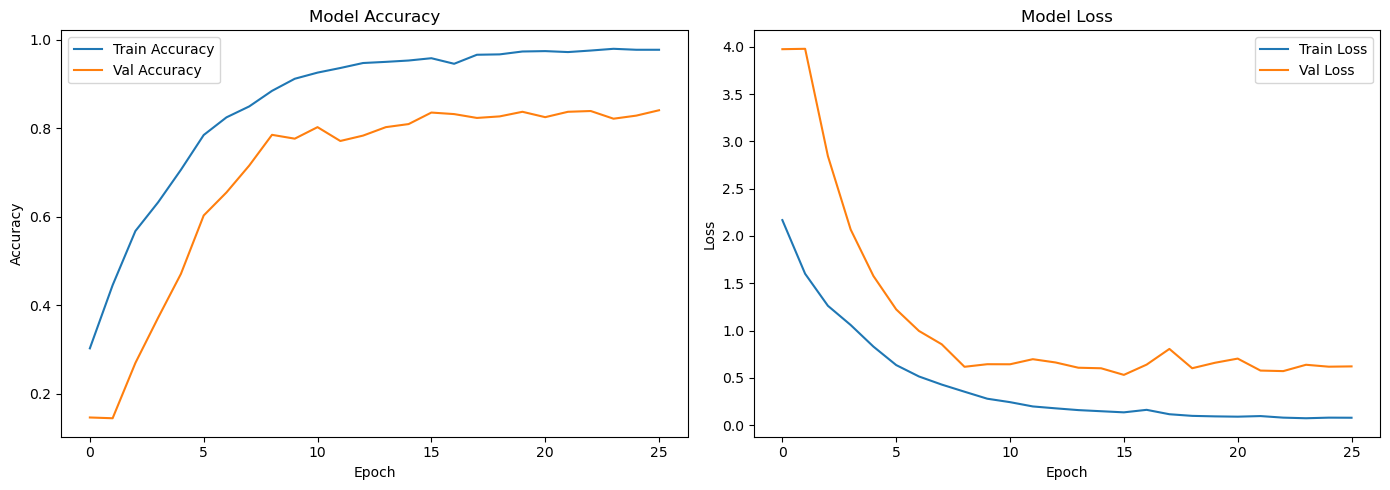

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy graph
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss graph
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_graphs.png')
plt.show()

---
## Step 13: Evaluate Model on Test Set
We evaluate the final model performance on training and test data to compare accuracies.

In [15]:
import seaborn as sns

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracies
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc  = model.evaluate(X_test, y_test, verbose=0)

print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Val Accuracy:   {max(history.history['val_accuracy'])*100:.2f}%")
print(f"Test Accuracy:  {test_acc*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step
Train Accuracy: 99.70%
Val Accuracy:   84.03%
Test Accuracy:  83.51%


---
## Step 14: Accuracy Bar Chart (Train vs Validation vs Test)
We visualize and compare train, validation, and test accuracies side by side.

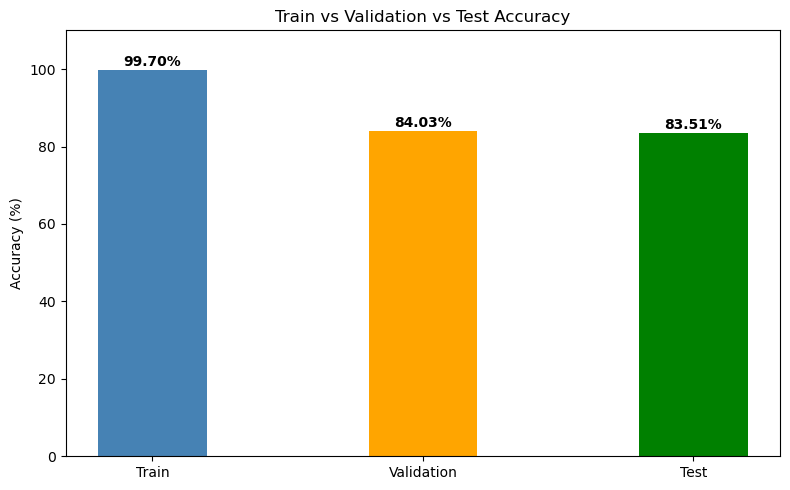

In [16]:
labels = ['Train', 'Validation', 'Test']
values = [
    train_acc * 100,
    max(history.history['val_accuracy']) * 100,
    test_acc * 100
]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=['steelblue', 'orange', 'green'], width=0.4)
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)')
plt.title('Train vs Validation vs Test Accuracy')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('accuracy_bar_chart.png')
plt.show()

---
## Step 15: Confusion Matrix
Plot the confusion matrix to see which emotions the model predicts correctly and where it confuses emotions.

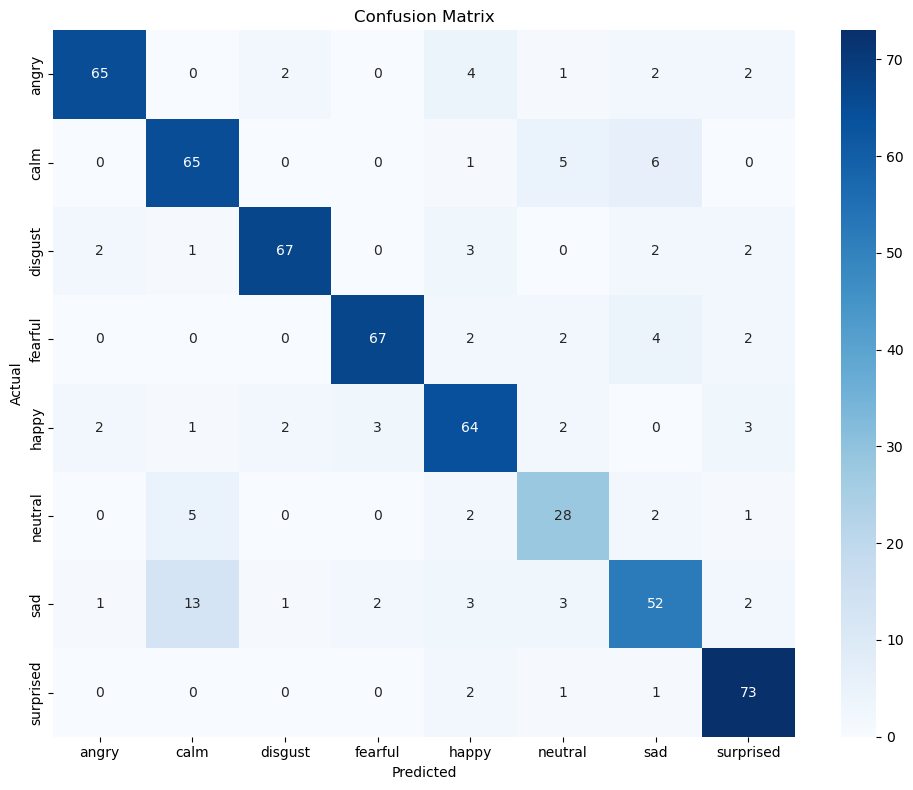

In [17]:
cm = confusion_matrix(y_test, y_pred)
emotion_labels = le.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

---
## Step 16: Classification Report
We print precision, recall, and F1-score for each emotion class to analyze per-class performance.

In [18]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=emotion_labels))

Classification Report:
              precision    recall  f1-score   support

       angry       0.93      0.86      0.89        76
        calm       0.76      0.84      0.80        77
     disgust       0.93      0.87      0.90        77
     fearful       0.93      0.87      0.90        77
       happy       0.79      0.83      0.81        77
     neutral       0.67      0.74      0.70        38
         sad       0.75      0.68      0.71        77
   surprised       0.86      0.95      0.90        77

    accuracy                           0.84       576
   macro avg       0.83      0.83      0.83       576
weighted avg       0.84      0.84      0.84       576



---
## Step 17: Predict Emotion from a Single Audio File
We define a prediction function that takes any .wav file and returns the predicted emotion with confidence score.

In [23]:
def predict_emotion(file_path):
    mfcc = extract_mfcc_augmented(file_path, augment=False)
    print("MFCC shape:", mfcc.shape)  # should be (40, 174)
    
    mfcc_reshaped = mfcc.reshape(1, -1)
    print("Reshaped:", mfcc_reshaped.shape)  # should be (1, 6960)
    
    mfcc_scaled = scaler.transform(mfcc_reshaped).reshape(1, 40, 174, 1)
    print("Scaled shape:", mfcc_scaled.shape)  # should be (1, 40, 174, 1)
    
    pred = model.predict(mfcc_scaled)
    print("Prediction probs:", pred)  # should NOT be 99%+ on one class
    
    emotion = le.inverse_transform([np.argmax(pred)])[0]
    confidence = np.max(pred) * 100
    print(f"Predicted Emotion: {emotion} ({confidence:.2f}% confidence)")
    return emotion

# Test multiple files and see results
test_files = [
    r"C:\Users\ORACLE\Speech_Emotion_Project/Audio_Speech_Actors_Datasets/Actor_21/03-01-07-02-01-01-21.wav", # disgust
    r"C:\Users\ORACLE\Speech_Emotion_Project/Audio_Speech_Actors_Datasets/Actor_21/03-01-08-01-01-02-21.wav", # surprised
    r"C:\Users\ORACLE\Speech_Emotion_Project/Audio_Speech_Actors_Datasets/Actor_21/03-01-04-02-01-02-21.wav", # sad
]

for f in test_files:
    print("---")
    predict_emotion(f)

---
MFCC shape: (40, 174)
Reshaped: (1, 6960)
Scaled shape: (1, 40, 174, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Prediction probs: [[8.6174830e-04 9.9079647e-05 9.9854469e-01 1.1709476e-05 3.0659378e-04
  8.6007050e-05 6.5416243e-05 2.4717503e-05]]
Predicted Emotion: disgust (99.85% confidence)
---
MFCC shape: (40, 174)
Reshaped: (1, 6960)
Scaled shape: (1, 40, 174, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step
Prediction probs: [[6.7958463e-05 3.4347110e-09 5.1815755e-06 9.5437315e-07 2.2495301e-04
  1.6078053e-05 4.0994965e-07 9.9968445e-01]]
Predicted Emotion: surprised (99.97% confidence)
---
MFCC shape: (40, 174)
Reshaped: (1, 6960)
Scaled shape: (1, 40, 174, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Prediction probs: [[1.4995720e-08 3.2342755e-06 1.0118271e-06 9.7095017e-07 6.1001601e-06
  3.2918756e-08 9.9998856e-01 1.7140725e-07]]
Predicted Emotion: sad (100.00% confidence)
MFCC shape: (40, 174)
Reshaped: (1, 6960)
Scaled shape: (1, 40, 174, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Pr

---
## Step 18: Interactive Gradio Interface
We build a simple web interface where a user can upload or record audio and get the predicted emotion in real time.

In [23]:
!pip install gradio

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of gradio to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of gradio to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/54.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/54.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/54.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/54.3 MB ? eta -:--:--
   -----------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [21]:
# pip install gradio
import gradio as gr

def gradio_predict(audio_file):
    emotion = predict_emotion(audio_file)
    return emotion

interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Audio(type="filepath", label="Upload or Record Audio"),
    outputs=gr.Label(label="Predicted Emotion"),
    title="Speech Emotion Recognition",
    description="Upload a .wav file to detect the emotion"
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


MFCC shape: (40, 174)
Reshaped: (1, 6960)
Scaled shape: (1, 40, 174, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Prediction probs: [[1.1337032e-05 9.9965847e-01 1.6575517e-05 8.0028753e-05 5.6005309e-05
  1.6366332e-04 1.2577020e-05 1.3692734e-06]]
Predicted Emotion: calm (99.97% confidence)


---
## 20. Conclusion

This project successfully implemented a **Speech Emotion Recognition (SER)** system using deep learning on the RAVDESS dataset, achieving a **test accuracy of 83.51%** across 8 emotion classes.

### Key Results
| Metric | Score |
|--------|-------|
| Train Accuracy | 99.70% |
| Validation Accuracy | 84.03% |
| Test Accuracy | 83.51% |

### Summary of Work
- Extracted **MFCC features** (40 coefficients) from 1440 raw audio files
- Applied **data augmentation** (noise injection, pitch shifting) to increase dataset to ~2880 samples
- Built a **3-layer CNN** with BatchNormalization and Dropout to reduce overfitting
- Used **Early Stopping** to automatically halt training at the optimal epoch
- Evaluated using confusion matrix, classification report, and accuracy comparisons
- Deployed a **real-time Gradio interface** for live emotion prediction from audio input

### Limitations
- A ~15% train-validation gap indicates moderate overfitting due to the small dataset size
- Model is trained on acted speech (RAVDESS) and may not generalize perfectly to natural, real-world speech

### Future Work
- Integrate transformer-based pretrained models such as **wav2vec 2.0** for improved accuracy
- Train on larger and more diverse datasets such as **CREMA-D** or **IEMOCAP**
- Deploy as a full web application with a persistent backend